In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import pickle
import pandas as pd
from pcm_models import find_model
import PcmPy as pcm
from matplotlib.patches import Patch

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [3]:
experiment = 'smp0'
epochs = ['Pre', 'SLR', 'LLR', 'Vol']

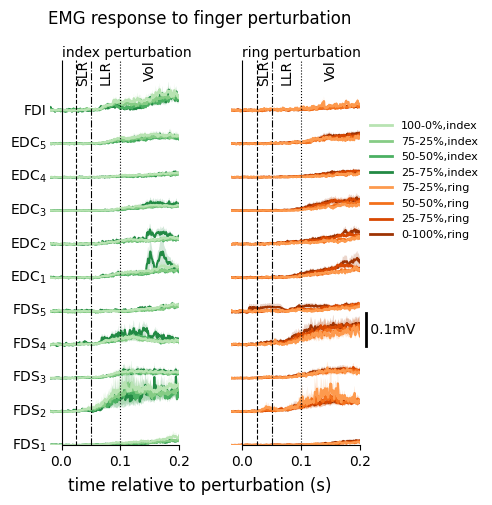

In [4]:
from vis import plot_emg_aligned

f = open(os.path.join(gl.baseDir, experiment, 'emg', 'emg.p'), 'rb')
emg = pickle.load(f)
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(4, 5))
fig, axs = plot_emg_aligned(fig, axs, emg)
plt.show()

Pre: tval=1.6556605346164892, pval=0.13217378788066925
SLR: tval=2.220763864345961, pval=0.05349731138961115
LLR: tval=5.707471950664005, pval=0.0002915376212158161
Vol: tval=14.443903483119529, pval=1.565491067322626e-07


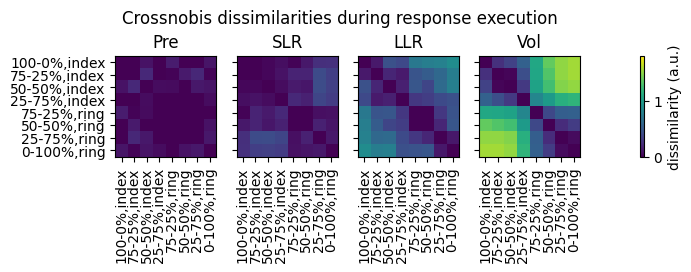

In [37]:
from vis import plot_dissimilarities

G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.npy'))
vmin, vmax = -0., 1.8
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
fig, axs = plt.subplots(1, 4, figsize=(6, 2), sharex=True, sharey=True)
for e, epoch in enumerate(epochs):
    D = pcm.G_to_dist(G[:, e])
    fig, axs = plot_dissimilarities(fig, axs, e, D, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=epoch)
    axs[e].set_title(epoch)
bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
im = axs[-1].images[0]
fig.colorbar(im, cax=cbar_ax).set_label('dissimilarity (a.u.)', )
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

Pre: 0.3586825221577216 upper noise
SLR: 0.32142072686895806 upper noise
LLR: 0.6152165414064779 upper noise
Vol: 0.7449794139592405 upper noise
Pre, tval=2.3854053722966273, pval=0.02043200835237465
SLR, tval=1.6994250642526638, pval=0.06172929005311001
LLR, tval=2.7917368224329557, pval=0.01049708635388353
Vol, tval=5.143034547931599, pval=0.00030440377390180724


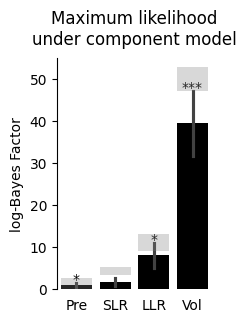

In [6]:
from vis import plot_likelihood

LL = {'epoch': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for epoch in epochs:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['epoch'].extend([epoch] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(2, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='epoch')
axs.set_ylim(0, 55)
axs.set_title('Maximum likelihood\nunder component model', pad=10)
plt.show()


Pre:
finger, tval=-3.8993869549496143, pval=0.99818860464209
cue, tval=-23.329766009666397, pval=0.9999999988371973
surprise, tval=-3.4546963823416186, pval=0.996389507609639
finger vs. cue, tval=0.41519648783573954, pval=0.6877213866165248
finger vs. surprise, tval=-2.0620047423977486, pval=0.0692549991867065
cue vs. surprise, tval=-3.8663591644294635, pval=0.003809885281588334

SLR:
finger, tval=1.1419269219773511, pval=0.14147724804263107
cue, tval=-0.6278836676907957, pval=0.7271599557880506
surprise, tval=-21.63950265554698, pval=0.9999999977364615
finger vs. cue, tval=1.3875739993814233, pval=0.19865801918656403
finger vs. surprise, tval=2.4706296828483376, pval=0.03553354298330897
cue vs. surprise, tval=1.7256303762986254, pval=0.11849471411670326

LLR:
finger, tval=2.2562575375289513, pval=0.02524221164545777
cue, tval=2.3331502485697975, pval=0.022258441259948563
surprise, tval=1.7746383912971935, pval=0.05485039321879403
finger vs. cue, tval=0.7920337910985232, pval=0.448712

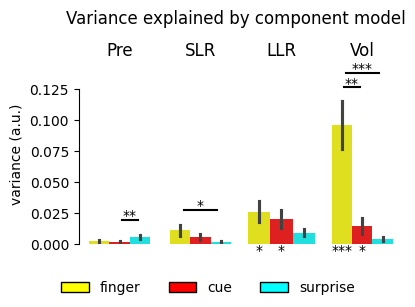

In [7]:
from vis import plot_var_expl, add_sig_comp_bayes, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['finger', 'cue', 'surprise']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components, basecomponents=np.eye(Mc.Gc.shape[1])[None, :, :])
palette =  ['#FFFF00', 'red', 'cyan']
figsize = (4, 3)
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
fig, axs = plt.subplots(1, len(epochs), figsize=figsize, sharey=True, )
for e, epoch in enumerate(epochs):
    f = open(os.path.join(pcm_path, f'theta_in.emg.{epoch}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = plot_var_expl(fig, axs, e, param_c, components=components, palette=palette)
for e, epoch in enumerate(epochs):
    print(f'\n{epoch}:')
    f = open(os.path.join(pcm_path, f'theta_in.emg.{epoch}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(pcm_path, f'T.model_family.emg.{epoch}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, e, c_bf)
    fig, axs = add_sig_var_expl(fig, axs, e, param_c, components)
    axs[e].set_title(epoch)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.suptitle('Variance explained by component model')
fig.subplots_adjust(bottom=.2, top=.8)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

Pre: correlation=-0.8009489761775838+/-0.18874206365378135
SLR: correlation=-0.4342554076477253+/-0.2227320218307841
LLR: correlation=0.4487431739585335+/-0.14364912694976484
Vol: correlation=0.7390311670654378+/-0.07352076318589977
Pre, tval=-4.025848301013367, pval=0.9985041974126329
SLR, tval=-1.8496256125960207, pval=0.9512955111852004
LLR, tval=2.9635763424967614, pval=0.007933540040937652
Vol, tval=9.536170389866435, pval=2.6527532185002112e-06


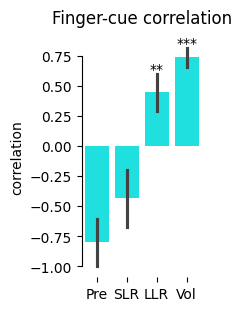

In [31]:
from vis import plot_interaction, add_sig_to_bars

Mf, idxf = find_model(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'M.exec.p'), 'feature')
n_param_f = Mf.n_param
interaction = {'epoch': [], 'interaction': [],}
pcm_path = os.path.join(gl.baseDir, experiment, gl.pcmDir)
for epoch in epochs:
    f = open(os.path.join(pcm_path, f'theta_in.emg.{epoch}.p'), "rb")
    param = pickle.load(f)[0]
    theta = param[:n_param_f]
    theta2 = theta ** 2
    covariance = theta[1] * theta[2]
    stds = np.sqrt((theta2[0] + theta2[1]) * theta2[2])
    correlation = covariance / stds
    print(f'{epoch}: correlation={correlation.mean()}+/-{correlation.std() / np.sqrt(correlation.size)}')
    interaction['epoch'].extend([epoch] * theta.shape[1])
    interaction['interaction'].extend(correlation if (np.isclose(stds, 0).sum() / stds.size) < .6 else [None] * theta.shape[1])
fig, ax = plt.subplots(figsize=(2, 3), constrained_layout=True)
fig, ax = plot_interaction(fig, ax, interaction, x='epoch')
fig, ax = add_sig_to_bars(fig, ax, interaction, y='interaction', x='epoch', alternative='greater')
ax.spines['left'].set_bounds(ax.get_yticks()[1], ax.get_yticks()[-2])
ax.set_title('Finger-cue correlation', pad=10)
plt.show()

group estimate:-0.9999999926874555 central 90% CI for r: [-1.000, 1.000]
Geom mean of variances: 2.602936669104334e-07, SD_err=1.4283562482995698; No reliable signal, discarding bootstrap resample
group estimate:-0.036143379356713426 central 90% CI for r: [-1.000, 0.670]
group estimate:0.646110329902124 central 90% CI for r: [0.432, 0.821]
group estimate:0.7740201256714457 central 90% CI for r: [0.691, 0.882]


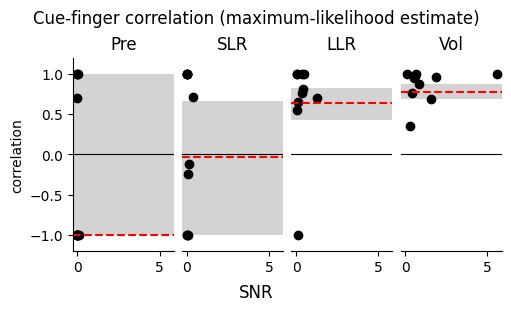

In [38]:
from vis import plot_pcm_corr

fig, axs = plt.subplots(1, len(epochs), sharex=True, sharey=True, figsize=(5, 3), constrained_layout=True)

for r, epoch in enumerate(epochs):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr_cue-finger.emg.{epoch}.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'r_bootstrap.corr_cue-finger.emg.{epoch}.npy'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr_cue-finger.emg.{epoch}.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, r, Mflex, theta, theta_g, r_bootstrap)
    axs[r].set_title(epoch)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-finger correlation (maximum-likelihood estimate)')

plt.show()
